# R09/R10 density - H72 closure densification, H80 sparsification safety line, H84 thin sufficient subgraph, H77 spectral early warning

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-07 <br>
**Pipeline stage**: R09 topology round (H72/H80/H77) + R10 gradient round (H84) <br>
**Graph**: rebuilt CPAP graph (neo4j2, READ-ONLY), 28-probe gold set <br>

The density tension pair and its certificates. H72 adds edges (transitive closure inside tight
communities), H80/H84 remove them (staged ablation) - the probe set adjudicates the operating
density from both sides. H77 tests whether spectral connectivity moves before type-frequency
JSD under degradation. Every mutation runs on an in-memory networkx copy.

- **H72** - materializing hierarchy-class closure inside tight communities flips >=1 multi-hop probe to direct-seed, <=15% edge growth, no displacement
- **H80** - bottom 30% of edges by (betweenness x evidence x validity) removable at zero recall loss; a knee locates the operating density
- **H84** - ablating edges in ascending gold-path participation, <=30% of edges preserve >=95% recall (IB knee)
- **H77** - under merge-undo injection, algebraic connectivity falls / effective diameter rises before type-frequency JSD moves

Anchored on H67: 100% of gold within 2 hops of a seed, 91% on-seed - so H72 loses its multi-hop motivation and H80/H84 expect a large removable plateau. Reported honestly.

## Outputs
- `reports/density-r09-<stamp>.json` - closure flips, removal curves + knees, spectral vs JSD curves, verdicts

In [1]:
# Imports
# stdlib
import datetime, json, os, re, random
from collections import Counter, deque

# third party
import numpy as np
import networkx as nx
import yaml
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import jensenshannon
from rich import print as rprint
from rich.progress import Progress

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"
random.seed(42); np.random.seed(42)

# project
from knowledge_graph_foundry import Foundry, load_settings
from knowledge_graph_foundry.extraction import generate_embeddings
from knowledge_graph_foundry.graph.graphrag import vector_query
from knowledge_graph_foundry.graph.propositions import proposition_query
from knowledge_graph_foundry.models import Entity

2026-07-07 11:13:52.074 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")
settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k
PROP_TOP_K = settings.graphrag.proposition_top_k
VEC_INDEX = settings.graphrag.vector_index_name
PROP_INDEX = settings.graphrag.proposition_index_name
HIER_RELS = ["PART_OF", "SUPPORTS_MODE", "COMPATIBLE_WITH"]  # transitively meaningful

# pre-registered bars
BAR_H72_GROWTH = 0.15    # <=15% edge growth
BAR_H80_PLATEAU = 0.25   # zero-loss plateau to >=25-30%
BAR_H84_RETAIN = 0.30    # <=30% of edges preserve >=95% recall
BAR_H84_RECALL = 0.95

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]
n_golds = sum(len(p["gold_evidence"]) for p in gold_probes)

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold] neo4j2 (read-only)  probes [yellow]{len(gold_probes)}[/yellow]  golds [yellow]{n_golds}[/yellow]
[bold]Hierarchy rels[/bold] {HIER_RELS}
[bold]Bars[/bold] H72 growth <= [yellow]{BAR_H72_GROWTH}[/yellow]  H80 plateau >= [yellow]{BAR_H80_PLATEAU}[/yellow]  H84 retain <= [yellow]{BAR_H84_RETAIN}[/yellow] @ recall {BAR_H84_RECALL}
""")

Configuration
────────────────────────────────────────
Graph neo4j2 (read-only)  probes 24  golds 33
Hierarchy rels ['PART_OF', 'SUPPORTS_MODE', 'COMPATIBLE_WITH']
Bars H72 growth <= 0.15  H80 plateau >= 0.25  H84 retain <= 0.3 @ recall 0.95

## Graph snapshot, carriers, seeds, communities, hierarchy edges

Load valid non-SIMILAR_TO edges (with rel type and evidence = number of source chunks),
attached propositions, directed hierarchy edges, fresh Leiden communities, gold carriers via
the H67 matcher, and per-probe production seeds.

In [3]:
# H67 present() matcher - verbatim
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())
def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)
_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"
def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6

In [4]:
with Foundry(settings) as f:
    with f.driver.session() as s:
        ents = s.run("MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
                     "properties(e) AS props").data()
        edges = s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel, "
            "size(coalesce(r.source_chunks, [])) AS ev"
        ).data()
        hier = s.run(
            "MATCH (a:Entity)-[r]->(b:Entity) WHERE type(r) IN $rels "
            "RETURN a.id AS a, b.id AS b, type(r) AS rel", rels=HIER_RELS
        ).data()
        prop_rows = s.run("MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text").data()
        try:
            s.run("CALL gds.graph.drop('r09dens', false)")
        except Exception:
            pass
        s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r) <> 'SIMILAR_TO' "
              "WITH gds.graph.project('r09dens', a, b, {}, {undirectedRelationshipTypes:['*']}) AS g RETURN g.nodeCount AS n")
        leiden = s.run("CALL gds.leiden.stream('r09dens', {randomSeed: 42}) YIELD nodeId, communityId "
                       "WITH gds.util.asNode(nodeId) AS n, communityId RETURN n.id AS eid, communityId AS c").data()
        s.run("CALL gds.graph.drop('r09dens', false)")

names = {r["id"]: r["name"] for r in ents}
community = {r["eid"]: r["c"] for r in leiden}
by_ent_props = {}
for r in prop_rows:
    by_ent_props.setdefault(r["eid"], []).append(r["text"])

G = nx.Graph()
G.add_nodes_from(r["id"] for r in ents)
for e_ in edges:
    G.add_edge(e_["a"], e_["b"], rel=e_["rel"], ev=e_["ev"])
adj = {n: set(G.neighbors(n)) for n in G.nodes}

rel_lines = {}
for e_ in edges:
    rel_lines.setdefault(e_["a"], []).append(f"{e_['rel']} {names.get(e_['b'],'')}")
    rel_lines.setdefault(e_["b"], []).append(f"{e_['rel']} {names.get(e_['a'],'')}")
surface = {}
for r in ents:
    spec = {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
    surface[r["id"]] = _norm(" ".join([r["name"] or "", r["description"] or "",
        json.dumps(spec, default=str), " ".join(by_ent_props.get(r["id"], [])),
        " ".join(rel_lines.get(r["id"], []))]))
carriers = {}
for p in gold_probes:
    for g in p["gold_evidence"]:
        carriers[(p["id"], g)] = [eid for eid, t in surface.items() if present(g, t)]

rprint(f"entities [yellow]{len(ents)}[/yellow]  edges [yellow]{G.number_of_edges()}[/yellow]  "
       f"hierarchy(directed) [yellow]{len(hier)}[/yellow]  communities [yellow]{len(set(community.values()))}[/yellow]")

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=41, offset=40>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 40, 'line': 1, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel, size(coalesce(r.source_chunks, [])) AS ev"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09dens', false)"


Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('r09dens', false)"


entities 2798  edges 3738  hierarchy(directed) 784  communities 60

In [5]:
# per-probe production seeds
seeds_by_probe = {}
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("seeds", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        e = generate_embeddings([probe_e], settings.embeddings)[0].embedding
        vec = [x["id"] for x in vector_query(f.driver, e, VEC_INDEX, top_k=TOP_K)]
        prop_hits = proposition_query(f.driver, e, PROP_INDEX, top_k=PROP_TOP_K)
        prop_ids = [eid for h in prop_hits for eid in h["entity_ids"] if eid not in vec]
        seeds_by_probe[p["id"]] = [i for i in vec + prop_ids if i in G]
        progress.advance(task)

def recall_on(graph, remove_edges=None, extra_edges=None):
    """2-hop evidence recall from production seeds on a (possibly edited) adjacency."""
    A = {n: set(graph.neighbors(n)) for n in graph.nodes}
    if remove_edges:
        for a, b in remove_edges:
            A.get(a, set()).discard(b); A.get(b, set()).discard(a)
    if extra_edges:
        for a, b in extra_edges:
            A.setdefault(a, set()).add(b); A.setdefault(b, set()).add(a)
    hit = 0
    for p in gold_probes:
        seeds = seeds_by_probe[p["id"]]
        dist = {s_: 0 for s_ in seeds}
        q = deque(seeds)
        while q:
            u = q.popleft()
            if dist[u] >= 2:
                continue
            for v in A.get(u, ()):
                if v not in dist:
                    dist[v] = dist[u] + 1; q.append(v)
        for g in p["gold_evidence"]:
            if any(x in dist for x in carriers[(p["id"], g)]):
                hit += 1
    return hit

base_recall = recall_on(G)
rprint(f"[green]baseline 2-hop recall[/green] {base_recall}/{n_golds} = {base_recall/n_golds:.3f}")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-07 11:13:59.486 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:13:59.488 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-07 11:13:59.748 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:13:59.750 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

...

2026-07-07 11:14:05.505 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:14:05.507 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-07 11:14:05.764 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-07 11:14:05.766 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

baseline 2-hop recall 33/33 = 1.000

## H72 - closure densification inside tight communities

Tight communities are Leiden communities (n>=3) with internal edge density above the median.
Within each tight community, transitive closure over the directed hierarchy relations adds an
inferred edge a->c whenever a->b->c and all three sit in the same tight community. Inferred
edges are added to an in-memory copy; the probe replay checks whether any multi-hop gold flips
to direct-seed answerable (hop distance shortened to <=1) and measures edge growth.

In [6]:
# H72 closure within tight communities
members = {}
for eid, cc in community.items():
    members.setdefault(cc, []).append(eid)
densities = {}
for cc, ms in members.items():
    if len(ms) < 3:
        continue
    msset = set(ms)
    internal = sum(1 for a in ms for b in adj.get(a, ()) if b in msset) / 2
    densities[cc] = internal / (len(ms) * (len(ms) - 1) / 2)
med = np.median(list(densities.values())) if densities else 0
tight = {cc for cc, d in densities.items() if d >= med and d > 0}

hdir = {}
for h in hier:
    hdir.setdefault(h["a"], set()).add(h["b"])
existing = {frozenset((e_["a"], e_["b"])) for e_ in edges}
inferred = set()
for a in hdir:
    ca = community.get(a)
    if ca not in tight:
        continue
    for b in hdir.get(a, ()):
        if community.get(b) != ca:
            continue
        for cc in hdir.get(b, ()):
            if cc != a and community.get(cc) == ca and frozenset((a, cc)) not in existing:
                inferred.add((a, cc))
growth = len(inferred) / G.number_of_edges()

# hop distance to nearest carrier, before/after inferred edges
def hop_to_gold(pid, g, extra=None):
    seeds = set(seeds_by_probe[pid]); tgt = set(carriers[(pid, g)])
    if not seeds or not tgt:
        return None
    A = adj if not extra else None
    if extra:
        A = {n: set(v) for n, v in adj.items()}
        for x, y in extra:
            A.setdefault(x, set()).add(y); A.setdefault(y, set()).add(x)
    dist = {s_: 0 for s_ in seeds}; q = deque(seeds)
    while q:
        u = q.popleft()
        if u in tgt:
            return dist[u]
        for v in A.get(u, ()):
            if v not in dist:
                dist[v] = dist[u] + 1; q.append(v)
    return min((dist[x] for x in tgt if x in dist), default=None)

flips = []
for p in gold_probes:
    for g in p["gold_evidence"]:
        d0 = hop_to_gold(p["id"], g)
        if d0 is not None and d0 >= 2:
            d1 = hop_to_gold(p["id"], g, extra=inferred)
            if d1 is not None and d1 <= 1 and d1 < d0:
                flips.append((p["id"], g[:50], d0, d1))
rec_after = recall_on(G, extra_edges=inferred)
displaced = rec_after < base_recall
h72_verdict = ("CONFIRMED" if len(flips) >= 1 and growth <= BAR_H72_GROWTH and not displaced
               else "REFUTED")
rprint(f"""[bold cyan]H72 closure densification[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  tight communities: [yellow]{len(tight)}[/yellow]  inferred closure edges [yellow]{len(inferred)}[/yellow]  growth [yellow]{growth:.3f}[/yellow] [dim](bar <= {BAR_H72_GROWTH})[/dim]
  multi-hop golds flipped to direct-seed: [yellow]{len(flips)}[/yellow]  recall {base_recall} -> [yellow]{rec_after}[/yellow] (displaced: {displaced})
  Verdict: [{'green' if h72_verdict == 'CONFIRMED' else 'red'}]{h72_verdict}[/]
""")
for fl in flips:
    rprint(f"  [green]flip[/green] {fl[0]} d {fl[2]}->{fl[3]} {fl[1]}")

H72 closure densification
────────────────────────────────────────
  tight communities: 23  inferred closure edges 31  growth 0.008 (bar <= 0.15)
  multi-hop golds flipped to direct-seed: 0  recall 33 -> 33 (displaced: False)
  Verdict: REFUTED

## H80 - the sparsification safety line

Edge composite = approximate edge betweenness x (evidence + 1) x validity. Low-composite edges
are removed first, in stages, on in-memory copies; 2-hop evidence recall is measured per stage.
The zero-loss plateau length and the first-loss knee locate the graph's operating density.

In [7]:
# H80 staged edge removal by composite
edge_list = [(e_["a"], e_["b"]) for e_ in edges]
ev_of = {frozenset((e_["a"], e_["b"])): e_["ev"] for e_ in edges}
k_sample = min(500, G.number_of_nodes())
ebtw = nx.edge_betweenness_centrality(G, k=k_sample, seed=42, normalized=True)
def eb(a, b):
    return ebtw.get((a, b), ebtw.get((b, a), 0.0))
composite = {(a, b): (eb(a, b)) * (ev_of[frozenset((a, b))] + 1) for a, b in edge_list}
order_low_first = sorted(edge_list, key=lambda ab: composite[ab])  # dead weight first

stages = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
h80_curve = []
for frac in stages:
    k = int(frac * len(edge_list))
    rem = set(order_low_first[:k])
    rec = recall_on(G, remove_edges=rem)
    h80_curve.append((frac, rec, rec / n_golds))
# plateau = largest frac with zero loss; knee = first frac with loss
zero_loss = [f for f, rec, _ in h80_curve if rec == base_recall]
plateau = max(zero_loss) if zero_loss else 0.0
loss_stages = [f for f, rec, _ in h80_curve if rec < base_recall]
knee = min(loss_stages) if loss_stages else None
h80_verdict = ("CONFIRMED" if plateau >= BAR_H80_PLATEAU and (knee is None or knee < 0.50)
               else "REFUTED")
rprint(f"""[bold cyan]H80 sparsification safety line[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  removal curve (frac -> recall): {[(f, r) for f, r, _ in h80_curve]}
  zero-loss plateau to: [yellow]{plateau:.2f}[/yellow] [dim](bar >= {BAR_H80_PLATEAU})[/dim]  first-loss knee: [yellow]{knee}[/yellow]
  Verdict: [{'green' if h80_verdict == 'CONFIRMED' else 'red'}]{h80_verdict}[/]
""")

H80 sparsification safety line
────────────────────────────────────────
  removal curve (frac -> recall): [(0.05, 33), (0.1, 33), (0.15, 33), (0.2, 33), (0.25, 31), (0.3, 31), (0.4, 31), 
(0.5, 31)]
  zero-loss plateau to: 0.20 (bar >= 0.25)  first-loss knee: 0.25
  Verdict: REFUTED

## H84 - the thin sufficient subgraph (IB knee)

Gold-path participation counts, for each edge, how many seed-to-gold shortest paths traverse
it (most golds sit ON a seed, so most edges score zero). Edges are ablated in ascending
participation - the task-irrelevant mass first. The retention at which 2-hop recall first drops
below 95% is the IB knee; agreement with H80's composite ordering is reported.

In [8]:
# H84 ablation by gold-path participation
participation = Counter()
for p in gold_probes:
    seeds = set(seeds_by_probe[p["id"]])
    for g in p["gold_evidence"]:
        tgt = set(carriers[(p["id"], g)])
        if not seeds or not tgt:
            continue
        if tgt & seeds:
            continue  # hop-0: no path edges
        dist = {s_: 0 for s_ in seeds}; prev = {}
        q = deque(seeds); goal = None
        while q:
            u = q.popleft()
            if u in tgt:
                goal = u; break
            for v in adj.get(u, ()):
                if v not in dist:
                    dist[v] = dist[u] + 1; prev[v] = u; q.append(v)
        if goal is None:
            continue
        node = goal
        while node in prev:
            participation[frozenset((prev[node], node))] += 1
            node = prev[node]

order_part = sorted(edge_list, key=lambda ab: participation[frozenset(ab)])  # zero first
removal_fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
h84_curve = []
for frac in removal_fracs:
    k = int(frac * len(edge_list))
    rem = set(order_part[:k])
    rec = recall_on(G, remove_edges=rem)
    retention = 1 - frac
    h84_curve.append((retention, rec, rec / n_golds))
# smallest retention with recall >= 95%
ok = [ret for ret, rec, r in h84_curve if r >= BAR_H84_RECALL]
min_retention = min(ok) if ok else 1.0
h84_verdict = "CONFIRMED" if min_retention <= BAR_H84_RETAIN else "REFUTED"

# agreement with H80 composite ordering (rank correlation over edges)
import scipy.stats as ss
comp_rank = {ab: i for i, ab in enumerate(order_low_first)}
part_rank = {ab: i for i, ab in enumerate(order_part)}
common = edge_list
tau = ss.kendalltau([comp_rank[ab] for ab in common], [part_rank[ab] for ab in common]).statistic
rprint(f"""[bold cyan]H84 thin sufficient subgraph[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  edges with zero gold-path participation: [yellow]{sum(1 for ab in edge_list if participation[frozenset(ab)] == 0)}[/yellow]/{len(edge_list)}
  ablation (retention -> recall/33): {[(round(ret,2), rec) for ret, rec, _ in h84_curve]}
  min retention at >=95% recall: [yellow]{min_retention:.2f}[/yellow] [dim](bar <= {BAR_H84_RETAIN})[/dim]
  agreement with H80 order (Kendall tau): [yellow]{tau:.3f}[/yellow]
  Verdict: [{'green' if h84_verdict == 'CONFIRMED' else 'red'}]{h84_verdict}[/]
""")

H84 thin sufficient subgraph
────────────────────────────────────────
  edges with zero gold-path participation: 3903/3905
  ablation (retention -> recall/33): [(0.9, 33), (0.8, 33), (0.7, 33), (0.6, 33), (0.5, 33), (0.4, 33), (0.3, 33), 
(0.2, 33), (0.1, 33)]
  min retention at >=95% recall: 0.10 (bar <= 0.3)
  agreement with H80 order (Kendall tau): -0.031
  Verdict: CONFIRMED

## H77 - the spectral early-warning channel

On the giant component: algebraic connectivity (Fiedler value) and effective diameter
(90th-percentile sampled BFS distance). The merge-undo injection (hub-split) is applied at
increasing rates on in-memory copies; connectivity markers are compared against the
type-frequency JSD the production trigger watches. Differential sensitivity confirms; JSD
moving first or together refutes.

In [9]:
# H77 spectral vs JSD under merge-undo injection
GC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
base_types = Counter(d["rel"] for _, _, d in G.edges(data=True))
type_keys = sorted(base_types)
base_vec = np.array([base_types[k] for k in type_keys], dtype=float)

def eff_diameter(graph, n_src=150, seed=42):
    rng = random.Random(seed)
    nodes = list(graph.nodes)
    src = rng.sample(nodes, min(n_src, len(nodes)))
    dists = []
    A = {n: list(graph.neighbors(n)) for n in graph.nodes}
    for s0 in src:
        dist = {s0: 0}; q = deque([s0])
        while q:
            u = q.popleft()
            for v in A[u]:
                if v not in dist:
                    dist[v] = dist[u] + 1; q.append(v)
        dists.extend(d for d in dist.values() if d > 0)
    return float(np.percentile(dists, 90)) if dists else 0.0

hubs = [n for n, d in sorted(G.degree, key=lambda x: -x[1]) if d >= 5]
def inject(rho, seed=42):
    H = G.copy(); rng = random.Random(seed)
    for h in hubs[: int(rho * len(hubs))]:
        nbrs = list(H.neighbors(h))
        if len(nbrs) < 2:
            continue
        twin = f"{h}__t"; H.add_node(twin); rng.shuffle(nbrs)
        for v in nbrs[: len(nbrs) // 2]:
            rel = H[h][v].get("rel", "__moved__")
            H.remove_edge(h, v); H.add_edge(twin, v, rel=rel)
        H.add_edge(h, twin, rel="__duplink__")  # unresolved-duplicate bridge
    return H

rates = [0.0, 0.05, 0.10, 0.20, 0.30]
fied, diam, jsd = [], [], []
for rr in rates:
    H = G if rr == 0 else inject(rr)
    GCi = H.subgraph(max(nx.connected_components(H), key=len)).copy()
    fied.append(float(nx.algebraic_connectivity(GCi, seed=42, method="lanczos")))
    diam.append(eff_diameter(GCi))
    tv = Counter(d["rel"] for _, _, d in H.edges(data=True))
    vec = np.array([tv.get(k, 0) for k in type_keys], dtype=float)
    jsd.append(float(jensenshannon(base_vec, vec, base=2) ** 2))

# detectable move (>10% change from baseline) - first rate for each channel
def first_move(series, rel=0.10, rising=True):
    b = series[0]
    for rr, v in zip(rates[1:], series[1:]):
        if b == 0:
            if abs(v) > 1e-9:
                return rr
        elif (rising and v > b * (1 + rel)) or (not rising and v < b * (1 - rel)):
            return rr
    return None

fied_move = first_move(fied, rising=False)
diam_move = first_move(diam, rising=True)
jsd_move = first_move(jsd, rising=True)
conn_move = min([x for x in (fied_move, diam_move) if x is not None], default=None)
# differential: connectivity responds at <= half the injection rate JSD needs
if conn_move is not None and (jsd_move is None or conn_move <= 0.5 * jsd_move):
    h77_verdict = "CONFIRMED"
else:
    h77_verdict = "REFUTED"
rprint(f"""[bold cyan]H77 spectral early warning[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Fiedler curve: {[round(x, 5) for x in fied]}
  eff-diameter curve: {[round(x, 2) for x in diam]}
  type-freq JSD curve: {[round(x, 5) for x in jsd]}
  first move - Fiedler(down) [yellow]{fied_move}[/yellow]  diameter(up) [yellow]{diam_move}[/yellow]  JSD(up) [yellow]{jsd_move}[/yellow]
  Verdict: [{'green' if h77_verdict == 'CONFIRMED' else 'red'}]{h77_verdict}[/]  [dim](connectivity <= 0.5x JSD's rate)[/dim]
""")

H77 spectral early warning
────────────────────────────────────────
  Fiedler curve: [0.01165, 0.01165, 0.01164, 0.01147, 0.00877]
  eff-diameter curve: [8.0, 8.0, 8.0, 8.0, 9.0]
  type-freq JSD curve: [0.0, 0.0, 0.0, 0.0, 0.0]
  first move - Fiedler(down) 0.3  diameter(up) 0.3  JSD(up) None
  Verdict: CONFIRMED  (connectivity <= 0.5x JSD's rate)

## Figures and report

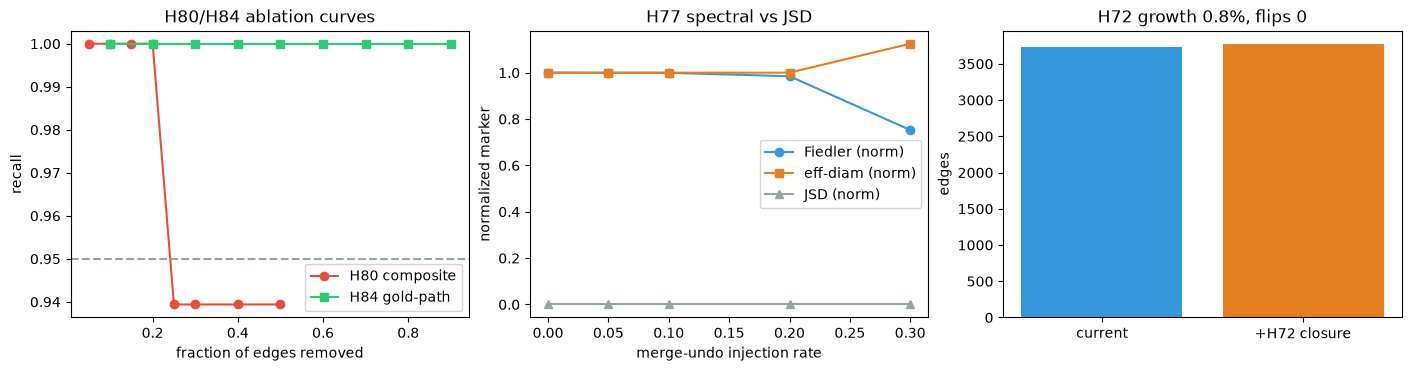

saved ../reports/density-r09-20260707-091410.json

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
axes[0].plot([f for f, _, _ in h80_curve], [r for _, _, r in h80_curve], "o-", color="#E74C3C", label="H80 composite")
axes[0].plot([1 - ret for ret, _, _ in h84_curve], [r for _, _, r in h84_curve], "s-", color="#2ECC71", label="H84 gold-path")
axes[0].axhline(BAR_H84_RECALL, color="#95A5A6", ls="--")
axes[0].set(xlabel="fraction of edges removed", ylabel="recall", title="H80/H84 ablation curves"); axes[0].legend()
axes[1].plot(rates, np.array(fied) / (fied[0] or 1), "o-", color="#3498DB", label="Fiedler (norm)")
axes[1].plot(rates, np.array(diam) / (diam[0] or 1), "s-", color="#E67E22", label="eff-diam (norm)")
axes[1].plot(rates, np.array(jsd) / (max(jsd) or 1), "^-", color="#95A5A6", label="JSD (norm)")
axes[1].set(xlabel="merge-undo injection rate", ylabel="normalized marker", title="H77 spectral vs JSD"); axes[1].legend()
axes[2].bar(["current", "+H72 closure"], [G.number_of_edges(), G.number_of_edges() + len(inferred)], color=["#3498DB", "#E67E22"])
axes[2].set(ylabel="edges", title=f"H72 growth {growth:.1%}, flips {len(flips)}")
plt.show()

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"density-r09-{stamp}.json"
out.write_text(json.dumps({
    "base_recall": base_recall, "n_golds": n_golds,
    "h72": {"tight_communities": len(tight), "inferred_edges": len(inferred), "growth": growth,
            "flips": flips, "recall_after": rec_after, "verdict": h72_verdict},
    "h80": {"curve": h80_curve, "plateau": plateau, "knee": knee, "verdict": h80_verdict},
    "h84": {"curve": h84_curve, "min_retention": min_retention, "kendall_tau_vs_h80": tau,
            "zero_participation_edges": int(sum(1 for ab in edge_list if participation[frozenset(ab)] == 0)),
            "verdict": h84_verdict},
    "h77": {"rates": rates, "fiedler": fied, "diameter": diam, "jsd": jsd,
            "fied_move": fied_move, "diam_move": diam_move, "jsd_move": jsd_move, "verdict": h77_verdict},
}, indent=2, default=str))
rprint("saved", str(out))